# 2. 평가 — 그림 + 통계치 저장

`result/predictions/*.csv` 를 로드해 지표를 계산하고,
- **통계치** → `result/statistics/metrics.csv`, `stage_r2.csv`
- **그림** → `result/image/metric_bars.png`, `scatter_grid.png`, `stage_r2.png`

**지표**: R²(설명력), MAE/RMSE(오차, 작을수록↑), Spearman ρ(순위 일치도, 높을수록↑ — 상대가치 랭킹).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from util import utils, file_manager as fm, plot
from util.metric import metrics, stage_r2
from module import data, infer

# 저장된 model weight 을 로드해 OOS test set 을 직접 forward (예측 CSV 미로드 → 가중치→예측 재현)
# 전 모델이 이론가(MC) 예측 (y_true=MC): 벤치마크=직접(단일 단계), DeepONet/XGB=하이브리드(2단계).
cfg = utils.load_config()
D = data.load(cfg)
preds = infer.predict_all_from_weights(D, cfg)
print("predicted from saved weights:", list(preds.keys()))

predicted from saved weights: ['bench_ridge', 'bench_gbm', 'bench_lgbm', 'bench_xgboost', 'bench_catboost', 'deeponet_hybrid', 'deeponet_hybrid_l1', 'deeponet_hybrid_mape', 'deeponet_hybrid_s2don', 'xgb_hybrid']


In [2]:
# 지표 표
rows, scat = [], {}
for name, df in preds.items():
    rows.append({"model": name, **metrics(df["y_true"], df["y_pred"])})
    scat[name] = (df["y_true"].values, df["y_pred"].values)
mt = pd.DataFrame(rows).set_index("model").sort_values("R2", ascending=False)
mt.to_csv(fm.stat("metrics"))
print(mt.round(4).to_string())

                           R2     MAE    RMSE   MAPE%  MdAPE%   Bias%  Spearman
model                                                                          
deeponet_hybrid_l1     0.9611  0.0036  0.0060  0.3728  0.2200 -0.1230    0.9872
deeponet_hybrid_mape   0.9594  0.0035  0.0061  0.3637  0.2003 -0.1207    0.9896
deeponet_hybrid        0.9571  0.0037  0.0063  0.3876  0.2183  0.0521    0.9787
deeponet_hybrid_s2don  0.9549  0.0037  0.0064  0.3801  0.2025  0.0927    0.9753
xgb_hybrid             0.9036  0.0061  0.0094  0.6314  0.3905 -0.2151    0.9630
bench_catboost         0.9024  0.0064  0.0094  0.6583  0.4424 -0.2868    0.9642
bench_xgboost          0.8539  0.0076  0.0115  0.7829  0.4679 -0.4483    0.9501
bench_gbm              0.8417  0.0081  0.0120  0.8356  0.5160 -0.4603    0.9453
bench_lgbm             0.8356  0.0081  0.0122  0.8394  0.4917 -0.5249    0.9523
bench_ridge            0.7010  0.0124  0.0165  1.2629  0.9586 -0.2692    0.8953


In [3]:
# stage별 R² (하이브리드)
st = {name: stage_r2(df) for name, df in preds.items() if stage_r2(df) is not None}
sdf = pd.DataFrame(st).T
sdf.to_csv(fm.stat("stage_r2"))
print(sdf.round(3).to_string())

                       stage1_MC_R2  stage2_resid_R2  final_MC_R2
deeponet_hybrid               0.951            0.126        0.957
deeponet_hybrid_l1            0.957            0.045        0.961
deeponet_hybrid_mape          0.950            0.153        0.959
deeponet_hybrid_s2don         0.949            0.109        0.955
xgb_hybrid                    0.897            0.005        0.904


## R² 상세 분석 — 과대평가(overprice) · 구간별 · 시간별

우리 MC는 자산별 **단일 역사변동성**(행사가별 스큐 없음 = 스큐가 평탄)이라 하방 꼬리위험을 과소반영 → 위험(저가) 구간에서 ELS를 **과대평가**하는 경향이 있다. 아래에서 모델별 **과대/과소평가(bias)**, 공정가치 **구간별 R²·MAPE·bias**, **발행시기별 R²**(시간 안정성), 그리고 **잔차-공정가치 곡선**(스큐 평탄화의 흔적)을 분해한다.

In [4]:
# 과대/과소평가(overprice) 분해 — bias>0 이면 평균적으로 과대평가 (단위: 원, 발행가 10,000)
import numpy as np
from sklearn.metrics import r2_score
FACE = 10000
base = next(iter(preds.values())).set_index("ITEM_CD")
idx = base.index
det = []
for name, df in preds.items():
    d = df.set_index("ITEM_CD").loc[idx]; yt = d["y_true"].values; yp = d["y_pred"].values
    e = yp - yt; over = e > 0                       # e>0 = 과대평가(overprice)
    det.append({"model": name, "R2": r2_score(yt, yp),
                "MAPE%": np.mean(np.abs(e) / np.abs(yt)) * 100,
                "over_frac%": over.mean() * 100,
                "bias_KRW": e.mean() * FACE,
                "overMAE_KRW": e[over].mean() * FACE if over.any() else 0.0,
                "underMAE_KRW": -e[~over].mean() * FACE if (~over).any() else 0.0})
detdf = pd.DataFrame(det).set_index("model").sort_values("R2", ascending=False)
detdf.to_csv(fm.stat("error_breakdown"))
print("과대/과소평가 분해 (over_frac% = 과대평가 비율, bias>0 = 과대평가):")
print(detdf.round(2).to_string())

과대/과소평가 분해 (over_frac% = 과대평가 비율, bias>0 = 과대평가):
                         R2  MAPE%  over_frac%   bias_KRW  overMAE_KRW  underMAE_KRW
model                                                                               
deeponet_hybrid_l1     0.96   0.37       35.11 -12.000000    34.000000     36.900002
deeponet_hybrid_mape   0.96   0.36       37.35 -11.680000    31.040001     37.150002
deeponet_hybrid        0.96   0.39       47.37   4.800000    44.529999     30.969999
deeponet_hybrid_s2don  0.95   0.38       49.76   8.670000    45.610001     27.900000
xgb_hybrid             0.90   0.63       43.02 -21.240000    46.490002     72.379997
bench_catboost         0.90   0.66       38.14 -28.600000    46.459999     74.870003
bench_xgboost          0.85   0.78       35.62 -44.060001    45.009998     93.339996
bench_gbm              0.84   0.84       37.50 -45.139999    48.180000    101.129997
bench_lgbm             0.84   0.84       35.75 -51.080002    42.529999    103.180000
bench_ridge    

In [5]:
# 공정가치 구간별 · 발행시기별 R² 분해 (핵심 모델)
KEY = [m for m in ["xgb_hybrid", "deeponet_hybrid", "deeponet_hybrid_l1", "deeponet_hybrid_mape",
                   "deeponet_hybrid_s2don", "bench_xgboost"] if m in preds]
fair = base["y_true"].values; ordv = base["isu_ord"].values
q = np.quantile(fair, [1/3, 2/3])
seg = np.where(fair <= q[0], "low(위험/저가)", np.where(fair <= q[1], "mid", "high(안전/고가)"))
segs = ["low(위험/저가)", "mid", "high(안전/고가)"]
print("=== 공정가치 3분위 구간별  R² / MAPE / bias(원) ===")
for name in KEY:
    d = preds[name].set_index("ITEM_CD").loc[idx]; yt = d["y_true"].values; yp = d["y_pred"].values
    print(f"[{name}]")
    for s in segs:
        m = seg == s; e = yp[m] - yt[m]
        print(f"   {s:14s} n={m.sum():5d}  R2={r2_score(yt[m], yp[m]):+.3f}  "
              f"MAPE={np.mean(np.abs(e)/np.abs(yt[m]))*100:5.2f}%  bias={e.mean()*FACE:+6.0f}원")
tb = np.quantile(ordv, [.25, .5, .75]); tbin = np.digitize(ordv, tb)
print("\n=== 발행시기 4구간별 R² (시간 안정성; P0=과거→P3=최근) ===")
for name in KEY:
    d = preds[name].set_index("ITEM_CD").loc[idx]; yt = d["y_true"].values; yp = d["y_pred"].values
    print(f"   {name:22s} " + "  ".join(f"P{b}:{r2_score(yt[tbin==b], yp[tbin==b]):+.3f}" for b in range(4)))

=== 공정가치 3분위 구간별  R² / MAPE / bias(원) ===
[xgb_hybrid]
   low(위험/저가)     n= 3087  R2=+0.722  MAPE= 0.92%  bias=   -22원
   mid            n= 3087  R2=-0.707  MAPE= 0.54%  bias=   -25원
   high(안전/고가)    n= 3087  R2=+0.430  MAPE= 0.43%  bias=   -17원
[deeponet_hybrid]
   low(위험/저가)     n= 3087  R2=+0.855  MAPE= 0.63%  bias=   +18원
   mid            n= 3087  R2=+0.392  MAPE= 0.29%  bias=    +0원
   high(안전/고가)    n= 3087  R2=+0.832  MAPE= 0.24%  bias=    -4원
[deeponet_hybrid_l1]
   low(위험/저가)     n= 3087  R2=+0.863  MAPE= 0.61%  bias=   -12원
   mid            n= 3087  R2=+0.520  MAPE= 0.28%  bias=   -14원
   high(안전/고가)    n= 3087  R2=+0.857  MAPE= 0.22%  bias=   -10원
[deeponet_hybrid_mape]
   low(위험/저가)     n= 3087  R2=+0.843  MAPE= 0.65%  bias=   -19원
   mid            n= 3087  R2=+0.633  MAPE= 0.24%  bias=    -9원
   high(안전/고가)    n= 3087  R2=+0.888  MAPE= 0.20%  bias=    -7원
[deeponet_hybrid_s2don]
   low(위험/저가)     n= 3087  R2=+0.850  MAPE= 0.61%  bias=   +24원
   mid            n= 3087  

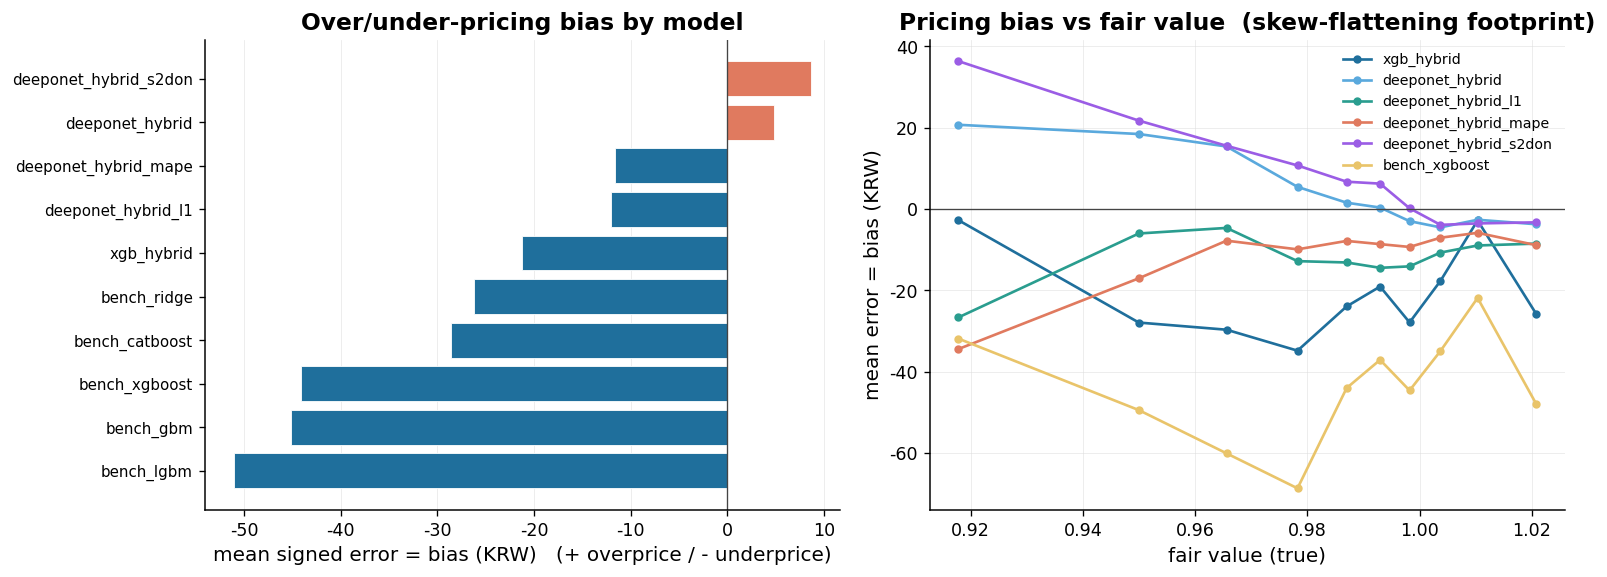

saved -> error_analysis.png


In [6]:
# 그림: (1) 모델별 과대/과소 bias  (2) 잔차 vs 공정가치 곡선 (스큐 평탄화 흔적)  [학술/PPT: dpi400·투명·콘텐츠밴드]
from util import plot as _plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13.333, 5.0))
mm = detdf.sort_values("bias_KRW")
ax[0].barh(range(len(mm)), mm["bias_KRW"].values,
           color=np.where(mm["bias_KRW"].values > 0, "#e07a5f", "#1f6f9c"), edgecolor="white", linewidth=0.5)
ax[0].set_yticks(range(len(mm))); ax[0].set_yticklabels(mm.index, fontsize=9)
ax[0].axvline(0, color="#444", lw=.8)
ax[0].set_xlabel("mean signed error = bias (KRW)   (+ overprice / - underprice)")
ax[0].set_title("Over/under-pricing bias by model")
ax[0].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6)
for j, name in enumerate(KEY):
    d = preds[name].set_index("ITEM_CD").loc[idx]; yt = d["y_true"].values; yp = d["y_pred"].values
    bins = np.quantile(yt, np.linspace(0, 1, 11)); ib = np.clip(np.digitize(yt, bins[1:-1]), 0, 9)
    xc = [yt[ib == k].mean() for k in range(10)]
    yb = [(yp[ib == k] - yt[ib == k]).mean() * FACE for k in range(10)]
    ax[1].plot(xc, yb, marker="o", ms=4, lw=1.6, color=_plot._QUAL[j % len(_plot._QUAL)], label=name)
ax[1].axhline(0, color="#444", lw=.8)
ax[1].set_xlabel("fair value (true)"); ax[1].set_ylabel("mean error = bias (KRW)")
ax[1].set_title("Pricing bias vs fair value  (skew-flattening footprint)")
ax[1].grid(color="#dddddd", lw=0.5, alpha=0.6)
ax[1].legend(fontsize=8.5)
fig.tight_layout()
fig.savefig(fm.image("error_analysis"), dpi=400, bbox_inches="tight", transparent=True); plt.show()
print("saved -> error_analysis.png")

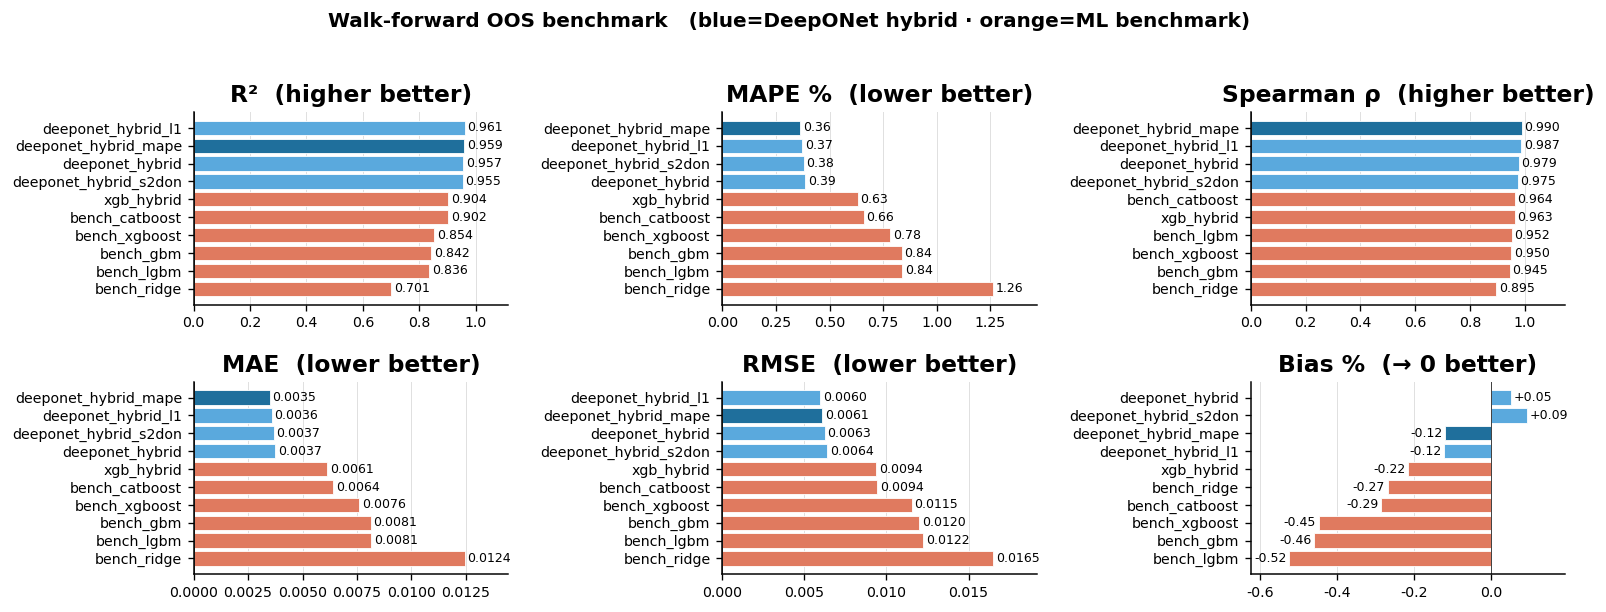

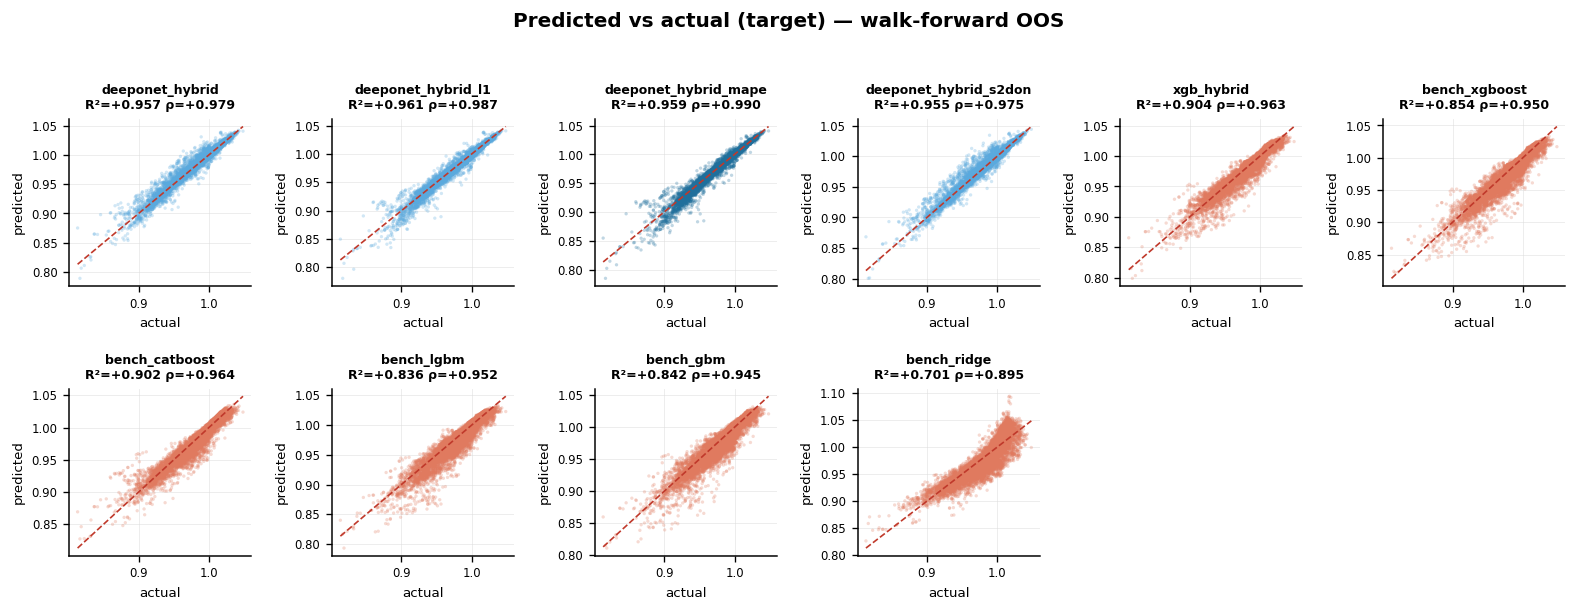

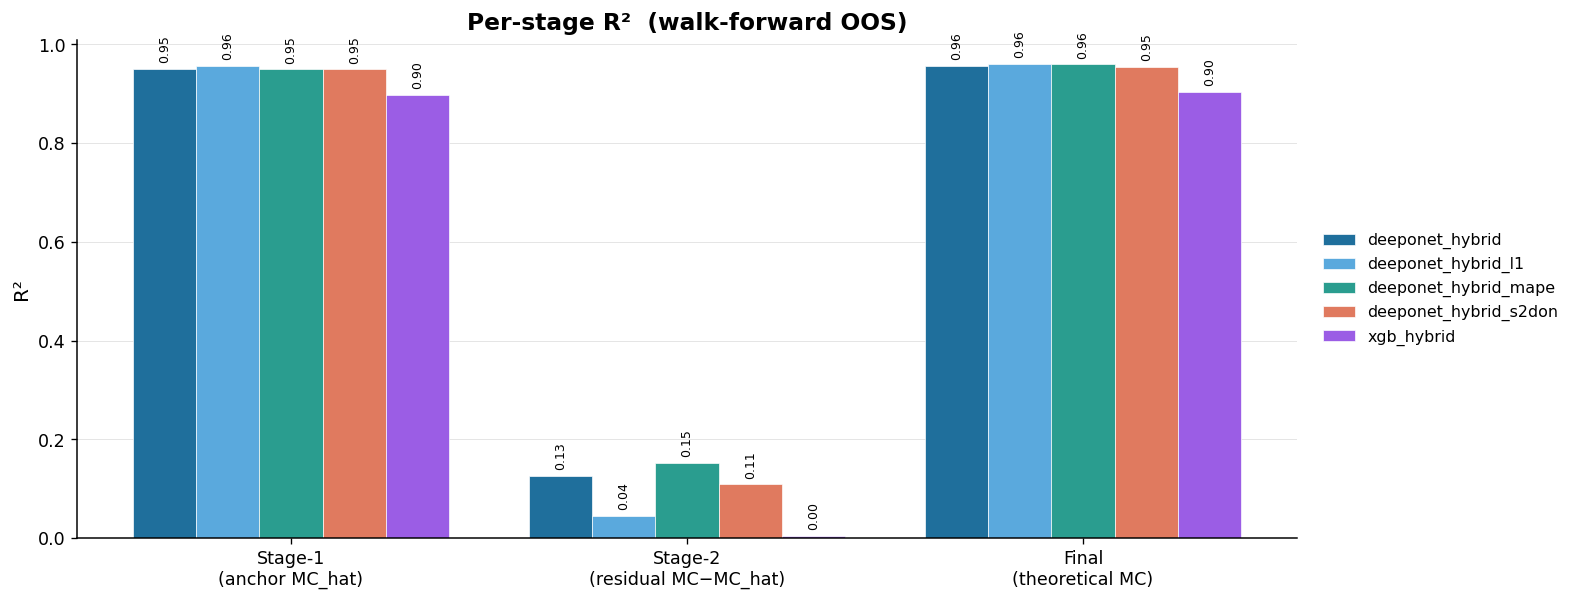

saved images -> ['error_analysis.png', 'fair_minus_mc_hist.png', 'impliedvol_rolling_match.png', 'mae_err_by_price_seg.png', 'mc_error_by_calibration.png', 'mc_error_precalib.png', 'mc_vs_deeponet_speed.png', 'metric_bars.png', 'raw_fair_tenor_hist.png', 'raw_filter_funnel.png', 'scatter_grid.png', 'stage_r2.png']
saved stats  -> ['error_breakdown.csv', 'metrics.csv', 'stage_r2.csv']


In [7]:
# 그림 저장 + 표시
ORDER = [
    "deeponet_hybrid",
    "deeponet_hybrid_l1",
    "deeponet_hybrid_mape",
    "deeponet_hybrid_s2don",
    "xgb_hybrid",
    "bench_xgboost",
    "bench_catboost",
    "bench_lgbm",
    "bench_gbm",
    "bench_ridge",
]
order = [m for m in ORDER if m in scat] + [m for m in scat if m not in ORDER]

plot.metric_bars(mt, fm.image("metric_bars"))
plot.scatter_grid(scat, order=order, path=fm.image("scatter_grid"))
if len(sdf):
    plot.stage_r2_bar(sdf, fm.image("stage_r2"))
plt.show()
print("saved images ->", [p.name for p in sorted(fm.IMAGE.glob("*.png"))])
print("saved stats  ->", [p.name for p in sorted(fm.STAT.glob("*.csv"))])

                         kind     n  batch_ms  per_product_us  products_per_sec
model                                                                          
deeponet_hybrid_s2don  hybrid  2315      1.07            0.46        2163248.03
bench_catboost         direct  2315      2.15            0.93        1076068.56
deeponet_hybrid        hybrid  2315      2.23            0.96        1038372.73
deeponet_hybrid_l1     hybrid  2315      2.23            0.96        1038139.85
deeponet_hybrid_mape   hybrid  2315      2.56            1.11         904650.24
bench_ridge            direct  2315      3.08            1.33         752649.74
xgb_hybrid             hybrid  2315      3.60            1.56         643046.62
bench_xgboost          direct  2315      6.11            2.64         379063.88
bench_gbm              direct  2315      8.14            3.52         284310.72
bench_lgbm             direct  2315      9.56            4.13         242167.48


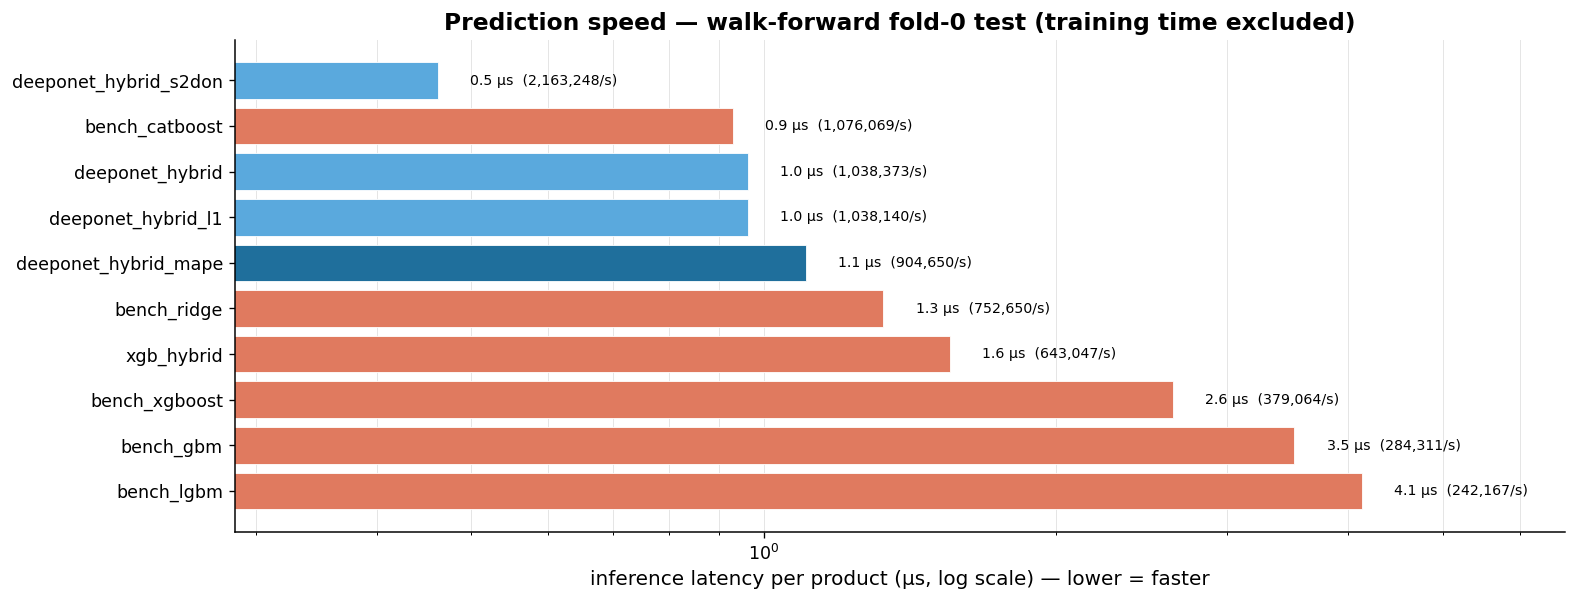

saved -> inference_speed.png | inference_speed.csv


In [8]:
# 예측(추론) 속도 측정 + 그래프  (학습 시간 제외, fold-0 test 기준)
from util import utils, speed
from module import data as _data
cfg = utils.load_config()
Dspd = _data.load(cfg)
spd = speed.measure(Dspd, cfg)
spd.to_csv(fm.stat("inference_speed"))
print(spd.round(2).to_string())
plot.speed_bar(spd, fm.image("inference_speed"))
plt.show()
print("saved ->", fm.image("inference_speed").name, "|", fm.stat("inference_speed").name)